# consistency of self calls
We are trying to see how reliably self echoes are heard and how consistent they are in the information they provide as oppposed to information coming from other direct calls/ echeos from their direct calls

Let us first load the data. 

In [7]:
import sys
import os 
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import itertools
import pickle
from mpl_toolkits.axes_grid1 import make_axes_locatable
os.chdir("/home/adityamoger/Documents/GitHub/dynamic_model_of_cocktail_party_nightmare/")

sys.path.append("./exploratory_analysis/")
sys.path.append("./dynamic_model/")
sys.path.append("./analysis_of_data/")
from snr_implementation import given_sound_objects_return_detected_sounds


from read_simulation_output import read_data_per_simulation_per_bat
from snr_implementation import given_sound_objects_return_detected_sounds, parse_sounds, serialize_sound_info
from supporting_files.utilities import make_dir

import bisect
plt.style.use("dark_background")

In [8]:
def make_ordered_lists_of_params(array_of_parameter_lists):
    product_of_lists = list(itertools.product(*array_of_parameter_lists))
    return product_of_lists

def reformat_matrices(nan_matrix, track_unique_objects):
    
    nan_matrix = nan_matrix.T
    
    sorting_indices = np.argsort(track_unique_objects)
    nan_matrix = nan_matrix[sorting_indices]
    track_unique_objects = np.array(track_unique_objects)[sorting_indices]
    
    # nan_matrix = nan_matrix[:, ~np.isnan(nan_matrix).all(0)]
    masked_array = np.ma.array(nan_matrix, mask=np.isnan(nan_matrix))
    
    return nan_matrix, track_unique_objects, masked_array

In [12]:
NUM_BATS = 1
TEMPORAL_MASKING_DIR = "./exploratory_analysis/temporal_masking_fn.csv"
DIRECTORY = f"/home/adityamoger/Documents/GitHub/dynamic_model_of_cocktail_party_nightmare/consistency_of_calls_movement_rule_data/walls_1_bat_scene/"
DIRECTORY_STORE_PLOTS = "./soundscape/plots/"

In [13]:
#store extracted data into a dict
# key needs to be some structure such that the parameters for that can be extracted. maybe ill just make it ordered

INCLUDE_DIRECT_SOUNDS_ARR = [True]
FOCAL_BATS = [0]
AZIMUTH_THRESHOLDS = [np.pi]

list_of_parameters = [FOCAL_BATS, INCLUDE_DIRECT_SOUNDS_ARR, AZIMUTH_THRESHOLDS]
ordered_list_of_parameters = make_ordered_lists_of_params(list_of_parameters)
labels_of_parameters = ["focal_bat", "include_direct_sounds", "azimuth_thresholds"]

In [14]:
dictionary_to_store_all_sounds = {}
dictionary_to_store_heard_sounds = {}
#keys of dictionary will be  the ordered param lists

for param in ordered_list_of_parameters:
    FOCAL_BAT, INCLUDE_DIRECT_SOUNDS, AZIMUTH  = param
    track_unique_objects = []
    sounds_to_plot = []
    times_of_sounds_to_plot = []
    delta_t = []
    OUTPUT_DIR = DIRECTORY + f"/{FOCAL_BAT}/"
    received_sounds_sorted_by_time = read_data_per_simulation_per_bat(
        OUTPUT_DIR, "received"
    )
    # print(received_sounds_sorted_by_time)
    if len(received_sounds_sorted_by_time)==0:
        raise ValueError("empty dir")

    nan_matrix = (
        np.zeros(
            shape=(len(received_sounds_sorted_by_time), NUM_BATS - 1 + 4)
        )
        * np.nan
    )
    list_of_heard_sounds = []
    for i, frame in enumerate(received_sounds_sorted_by_time):
        heard_sounds = parse_sounds(frame, time_threshold_post_call=0.02, angle_threshold=AZIMUTH, focal_bat=FOCAL_BAT, include_direct_sounds=INCLUDE_DIRECT_SOUNDS)
        heard_sounds = serialize_sound_info(heard_sounds)
        list_of_heard_sounds.append(heard_sounds)
    dictionary_to_store_heard_sounds[param] = list_of_heard_sounds
    # dictionary_to_store_all_sounds[param] = received_sounds_sorted_by_time
    print(param)

(0, True, 3.141592653589793)


In [15]:
dictionary_to_store_heard_sounds

{(0, True, 3.141592653589793): [[],
  [{'all_spl_values': [np.float64(74.22732463727088),
     np.float64(74.23452103049851),
     np.float64(74.24171929561027),
     np.float64(74.24892756167733)],
    'occurance_times': [np.float64(0.019),
     np.float64(0.0195),
     np.float64(0.02),
     np.float64(0.0205)],
    'ids': [UUID('49c74002-e75f-40be-b3c6-3010e285e120'),
     UUID('49c74002-e75f-40be-b3c6-3010e285e120'),
     UUID('49c74002-e75f-40be-b3c6-3010e285e120'),
     UUID('49c74002-e75f-40be-b3c6-3010e285e120')],
    'emitter_id': 0,
    'bat_direction': Vector(-0.564, -0.826),
    'incident_direction': Vector(0.017, -1.379),
    'type': 'echo',
    'reflected_from': 'wall_down',
    'sound_object_id': UUID('49c74002-e75f-40be-b3c6-3010e285e120'),
    'bat_last_call_time': np.float64(0.0105),
    'received_spl': np.float64(74.238),
    'time': np.float64(0.019),
    'duration': np.float64(0.003)},
   {'all_spl_values': [np.float64(51.59204813314189),
     np.float64(51.6004220

In [16]:
import pickle
with open(DIRECTORY+'/heard_sounds_data.pkl', 'wb') as fp:
    pickle.dump(dictionary_to_store_heard_sounds, fp)
# with open(f'/media/adityamoger/T7 Shield/consistency_of_calls/no_call_directionality/DATA_effect_of_group_size/{NUM_BATS}/all_sounds_data.pkl', 'wb') as fp:
#     pickle.dump(dictionary_to_store_all_sounds, fp)

In [8]:
# with open(f'/media/adityamoger/T7 Shield1/consistency_of_calls/no_call_directionality/DATA_effect_of_group_size/{NUM_BATS}/heard_sounds_data.pkl', 'rb') as fp:
#     dictionary_to_store_heard_sounds = pickle.load(fp)
# with open(f'/media/adityamoger/T7 Shield/consistency_of_calls/DATA_effect_of_group_size/{NUM_BATS}/180_90_30_1_7_17_data/all_sounds_data.pkl', 'rb') as fp:
#     dictionary_to_store_all_sounds = pickle.load(fp)

In [17]:
dictionary_to_store_heard_sounds[(1, True, 3.141592653589793)]

KeyError: (1, True, 3.141592653589793)

lets plot consistency of self calls. 
the labels are sorted by dictionary ordering. 

In [18]:
INCLUDE_DIRECT_SOUNDS_ARR = [True]
FOCAL_BATS = [0]
AZIMUTH_THRESHOLDS = [np.pi]

list_of_parameters_sublist = [FOCAL_BATS, INCLUDE_DIRECT_SOUNDS_ARR, AZIMUTH_THRESHOLDS]
ordered_list_of_parameters_sublist = make_ordered_lists_of_params(list_of_parameters_sublist)
# labels_of_parameters = ["focal_bat", "include_direct_sounds", "azimuth_thresholds"]
print(ordered_list_of_parameters_sublist)

[(0, True, 3.141592653589793)]


In [22]:
%matplotlib inline
store_matrices_given_param_theta = []
store_unique_objects_theta = []
store_masked_array_theta = []
for param in ordered_list_of_parameters_sublist:
    FOCAL_BAT, INCLUDE_DIRECT_SOUNDS, AZIMUTH  = param
    track_unique_objects = []

    heard_sounds_array = dictionary_to_store_heard_sounds[param]
    
    nan_matrix_theta_self_echoes = (
        np.zeros(
            shape=(len(heard_sounds_array), NUM_BATS - 1 + 50)
        )
        * np.nan
    )
    nan_matrix_theta_direct = (
        np.zeros(
            shape=(len(heard_sounds_array), NUM_BATS - 1 + 50)
        )
        * np.nan
    )
    nan_matrix_theta_non_self_echoes = (
        np.zeros(
            shape=(len(heard_sounds_array), NUM_BATS - 1 + 50)
        )
        * np.nan
    )
    
    for i, frame_heard_sounds in enumerate(heard_sounds_array):
        
        for sound_object in frame_heard_sounds:

            theta = sound_object["bat_direction"].angle_between(
                sound_object["incident_direction"]
            )

            if sound_object["emitter_id"] == FOCAL_BAT and sound_object["type"] == "echo":
                reflected_from = sound_object["reflected_from"]
                if reflected_from not in track_unique_objects:
                    track_unique_objects.append(reflected_from)
                index = track_unique_objects.index(reflected_from)
                print(track_unique_objects)
                print([i,index])
                nan_matrix_theta_self_echoes[i, index] = theta
                
            elif sound_object["emitter_id"] != FOCAL_BAT and sound_object["type"] == "echo":
                # print(sound_object["emitter_id"])
                reflected_from = sound_object["reflected_from"]
                if reflected_from not in track_unique_objects:
                    track_unique_objects.append(reflected_from)
                index = track_unique_objects.index(reflected_from)
                # print(track_unique_objects)
                
                nan_matrix_theta_non_self_echoes[i, index] = theta
            
            elif sound_object["emitter_id"] != FOCAL_BAT and sound_object["type"] == "direct":
                emitter = f"bat_{sound_object["emitter_id"]}"
                if emitter not in track_unique_objects:
                    track_unique_objects.append(emitter)
                index = track_unique_objects.index(emitter)
                
                nan_matrix_theta_direct[i, index] = theta
        
    nan_matrix_theta_direct, unique_direct, masked_array_direct= reformat_matrices(nan_matrix_theta_direct, track_unique_objects)
    nan_matrix_theta_self_echoes, unique_self_echoes_from, masked_array_self_echoes = reformat_matrices(nan_matrix_theta_self_echoes, track_unique_objects)  
    nan_matrix_theta_non_self_echoes, unique_non_self_echoes_from, masked_array_non_self_echoes = reformat_matrices(nan_matrix_theta_non_self_echoes, track_unique_objects)
    
    store_matrices_given_param_theta.append([nan_matrix_theta_self_echoes, nan_matrix_theta_direct, nan_matrix_theta_non_self_echoes])
    store_unique_objects_theta.append(unique_self_echoes_from)
    store_masked_array_theta.append([masked_array_self_echoes, masked_array_direct, masked_array_non_self_echoes])
    

['wall_down']
[1, 0]
['wall_down', 'obstacle_38']
[1, 1]
['wall_down', 'obstacle_38', 'obstacle_39']
[1, 2]
['wall_down', 'obstacle_38', 'obstacle_39', 'obstacle_37']
[1, 3]
['wall_down', 'obstacle_38', 'obstacle_39', 'obstacle_37', 'obstacle_40']
[1, 4]
['wall_down', 'obstacle_38', 'obstacle_39', 'obstacle_37', 'obstacle_40', 'obstacle_41']
[1, 5]
['wall_down', 'obstacle_38', 'obstacle_39', 'obstacle_37', 'obstacle_40', 'obstacle_41', 'obstacle_36']
[1, 6]
['wall_down', 'obstacle_38', 'obstacle_39', 'obstacle_37', 'obstacle_40', 'obstacle_41', 'obstacle_36', 'obstacle_42']
[1, 7]
['wall_down', 'obstacle_38', 'obstacle_39', 'obstacle_37', 'obstacle_40', 'obstacle_41', 'obstacle_36', 'obstacle_42', 'obstacle_35']
[1, 8]
['wall_down', 'obstacle_38', 'obstacle_39', 'obstacle_37', 'obstacle_40', 'obstacle_41', 'obstacle_36', 'obstacle_42', 'obstacle_35', 'obstacle_43']
[1, 9]
['wall_down', 'obstacle_38', 'obstacle_39', 'obstacle_37', 'obstacle_40', 'obstacle_41', 'obstacle_36', 'obstacle_4

In [24]:
store_matrices_given_param_delta_t = []
store_unique_objects_delta_t = []
store_masked_array_delta_t = []
for param in ordered_list_of_parameters_sublist:
    FOCAL_BAT, INCLUDE_DIRECT_SOUNDS, AZIMUTH  = param
    track_unique_objects = []

    heard_sounds_array = dictionary_to_store_heard_sounds[param]
    
    nan_matrix_delta_t_self_echoes = (
        np.zeros(
            shape=(len(heard_sounds_array), NUM_BATS - 1 + 50)
        )
        * np.nan
    )
    nan_matrix_delta_t_direct = (
        np.zeros(
            shape=(len(heard_sounds_array), NUM_BATS - 1 + 50)
        )
        * np.nan
    )
    nan_matrix_delta_t_non_self_echoes = (
        np.zeros(
            shape=(len(heard_sounds_array), NUM_BATS - 1 + 50)
        )
        * np.nan
    )
    counter= 0
    for i, frame_heard_sounds in enumerate(heard_sounds_array):
        
        for sound_object in frame_heard_sounds:
            print(sound_object)
            delta_t = np.array(sound_object["occurance_times"])[0] - sound_object["bat_last_call_time"]

            if sound_object["emitter_id"] == FOCAL_BAT:
                counter+=1
                reflected_from = sound_object["reflected_from"]
                if reflected_from not in track_unique_objects:
                    track_unique_objects.append(reflected_from)
                index = track_unique_objects.index(reflected_from)
                
                nan_matrix_delta_t_self_echoes[i, index] = delta_t
                
            elif sound_object["emitter_id"] != FOCAL_BAT and sound_object["type"] == "echo":
                reflected_from = sound_object["reflected_from"]
                if reflected_from not in track_unique_objects:
                    track_unique_objects.append(reflected_from)
                index = track_unique_objects.index(reflected_from)
                # print(track_unique_objects)
                nan_matrix_delta_t_non_self_echoes[i, index] = delta_t
            
            elif sound_object["emitter_id"] != FOCAL_BAT and sound_object["type"] == "direct":
                emitter = f"bat_{sound_object["emitter_id"]}"
                if emitter not in track_unique_objects:
                    track_unique_objects.append(emitter)
                index = track_unique_objects.index(emitter)
                
                nan_matrix_delta_t_direct[i, index] = delta_t
    print(counter)
    nan_matrix_delta_t_direct, unique_direct, masked_array_direct= reformat_matrices(nan_matrix_delta_t_direct, track_unique_objects)
    nan_matrix_delta_t_self_echoes, unique_self_echoes_from, masked_array_self_echoes = reformat_matrices(nan_matrix_delta_t_self_echoes, track_unique_objects)  
    nan_matrix_delta_t_non_self_echoes, unique_non_self_echoes_from, masked_array_non_self_echoes = reformat_matrices(nan_matrix_delta_t_non_self_echoes, track_unique_objects)
    
    store_matrices_given_param_delta_t.append([nan_matrix_delta_t_self_echoes, nan_matrix_delta_t_direct, nan_matrix_delta_t_non_self_echoes])
    store_unique_objects_delta_t.append(unique_self_echoes_from)
    store_masked_array_delta_t.append([masked_array_self_echoes, masked_array_direct, masked_array_non_self_echoes])
    

{'all_spl_values': [np.float64(74.22732463727088), np.float64(74.23452103049851), np.float64(74.24171929561027), np.float64(74.24892756167733)], 'occurance_times': [np.float64(0.019), np.float64(0.0195), np.float64(0.02), np.float64(0.0205)], 'ids': [UUID('49c74002-e75f-40be-b3c6-3010e285e120'), UUID('49c74002-e75f-40be-b3c6-3010e285e120'), UUID('49c74002-e75f-40be-b3c6-3010e285e120'), UUID('49c74002-e75f-40be-b3c6-3010e285e120')], 'emitter_id': 0, 'bat_direction': Vector(-0.564, -0.826), 'incident_direction': Vector(0.017, -1.379), 'type': 'echo', 'reflected_from': 'wall_down', 'sound_object_id': UUID('49c74002-e75f-40be-b3c6-3010e285e120'), 'bat_last_call_time': np.float64(0.0105), 'received_spl': np.float64(74.238), 'time': np.float64(0.019), 'duration': np.float64(0.003)}
{'all_spl_values': [np.float64(51.59204813314189), np.float64(51.600422032219974), np.float64(51.608801780894375), np.float64(51.617191261886575)], 'occurance_times': [np.float64(0.019), np.float64(0.0195), np.flo

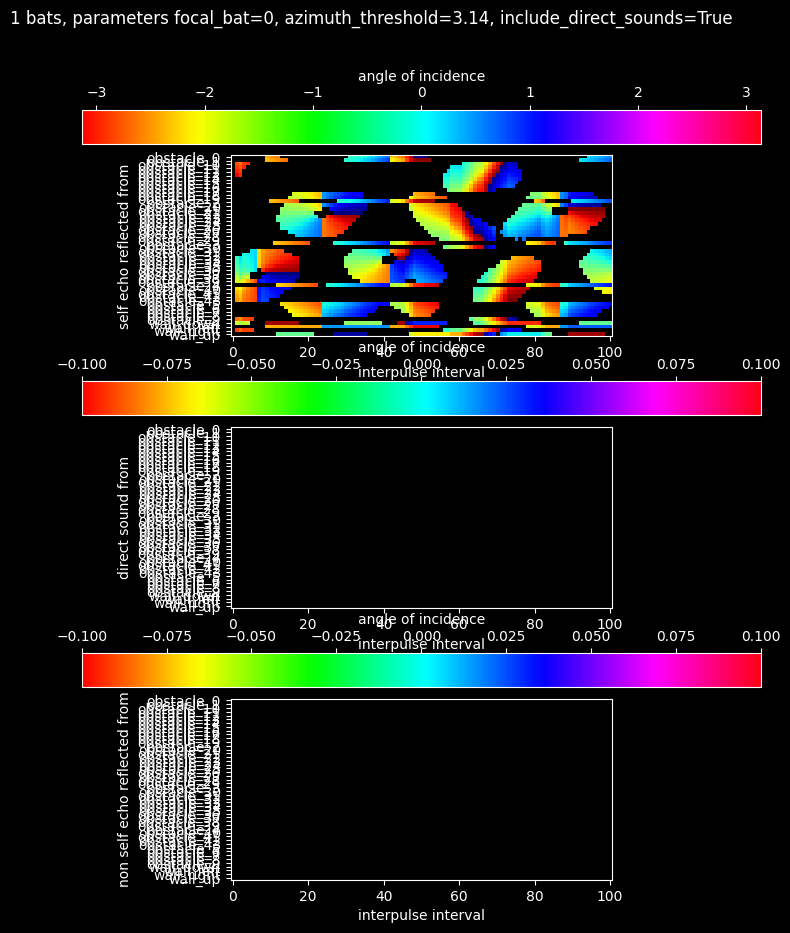

<Figure size 640x480 with 0 Axes>

In [25]:
for i, param in enumerate(ordered_list_of_parameters_sublist):
    FOCAL_BAT, INCLUDE_DIRECT_SOUNDS, AZIMUTH  = param
    
    list_of_matrices = store_matrices_given_param_theta[i]
    track_unique_objects = store_unique_objects_theta[i]
    masked_arrays_given_param = store_masked_array_theta[i]
    
    cmap_masked = mpl.cm.jet
    cmap_masked.set_bad('black',1.)
    
    
    plt.figure(figsize=(40, 10))
    plt.subplot(3,1,1)
    plt.imshow(list_of_matrices[0], cmap=mpl.colormaps["hsv"])
    plt.colorbar(
        location="top",
        label="angle of incidence",
    )
    plt.ylabel("self echo reflected from")
    plt.xlabel("interpulse interval")
    plt.yticks(
        labels=track_unique_objects, ticks=np.arange(0, list_of_matrices[0].shape[0])
    )
    plt.imshow(masked_arrays_given_param[0], interpolation='nearest', cmap=cmap_masked)
    plt.clim(-np.pi, np.pi)
    
    plt.subplot(3,1,2)
    plt.imshow(list_of_matrices[1], cmap=mpl.colormaps["hsv"])
    plt.colorbar(
        location="top",
        label="angle of incidence",
    )
    plt.ylabel("direct sound from")
    plt.xlabel("interpulse interval")
    plt.yticks(
        labels=track_unique_objects, ticks=np.arange(0, list_of_matrices[0].shape[0])
    )
    plt.imshow(masked_arrays_given_param[1], interpolation='nearest', cmap=cmap_masked)
    plt.clim(-np.pi, np.pi)
    
    plt.subplot(3,1,3)
    plt.imshow(list_of_matrices[2], cmap=mpl.colormaps["hsv"])
    plt.colorbar(
        location="top",
        label="angle of incidence",
    )
    plt.ylabel("non self echo reflected from")
    plt.xlabel("interpulse interval")
    plt.yticks(
        labels=track_unique_objects, ticks=np.arange(0, list_of_matrices[0].shape[0])
    )
    plt.imshow(masked_arrays_given_param[2], interpolation='nearest', cmap=cmap_masked)
    plt.clim(-np.pi, np.pi)
    
    plt.suptitle(f"{NUM_BATS} bats, parameters focal_bat={FOCAL_BAT}, azimuth_threshold={np.round(AZIMUTH,2)}, include_direct_sounds={INCLUDE_DIRECT_SOUNDS}")
    plt.show()
    plt.clf()

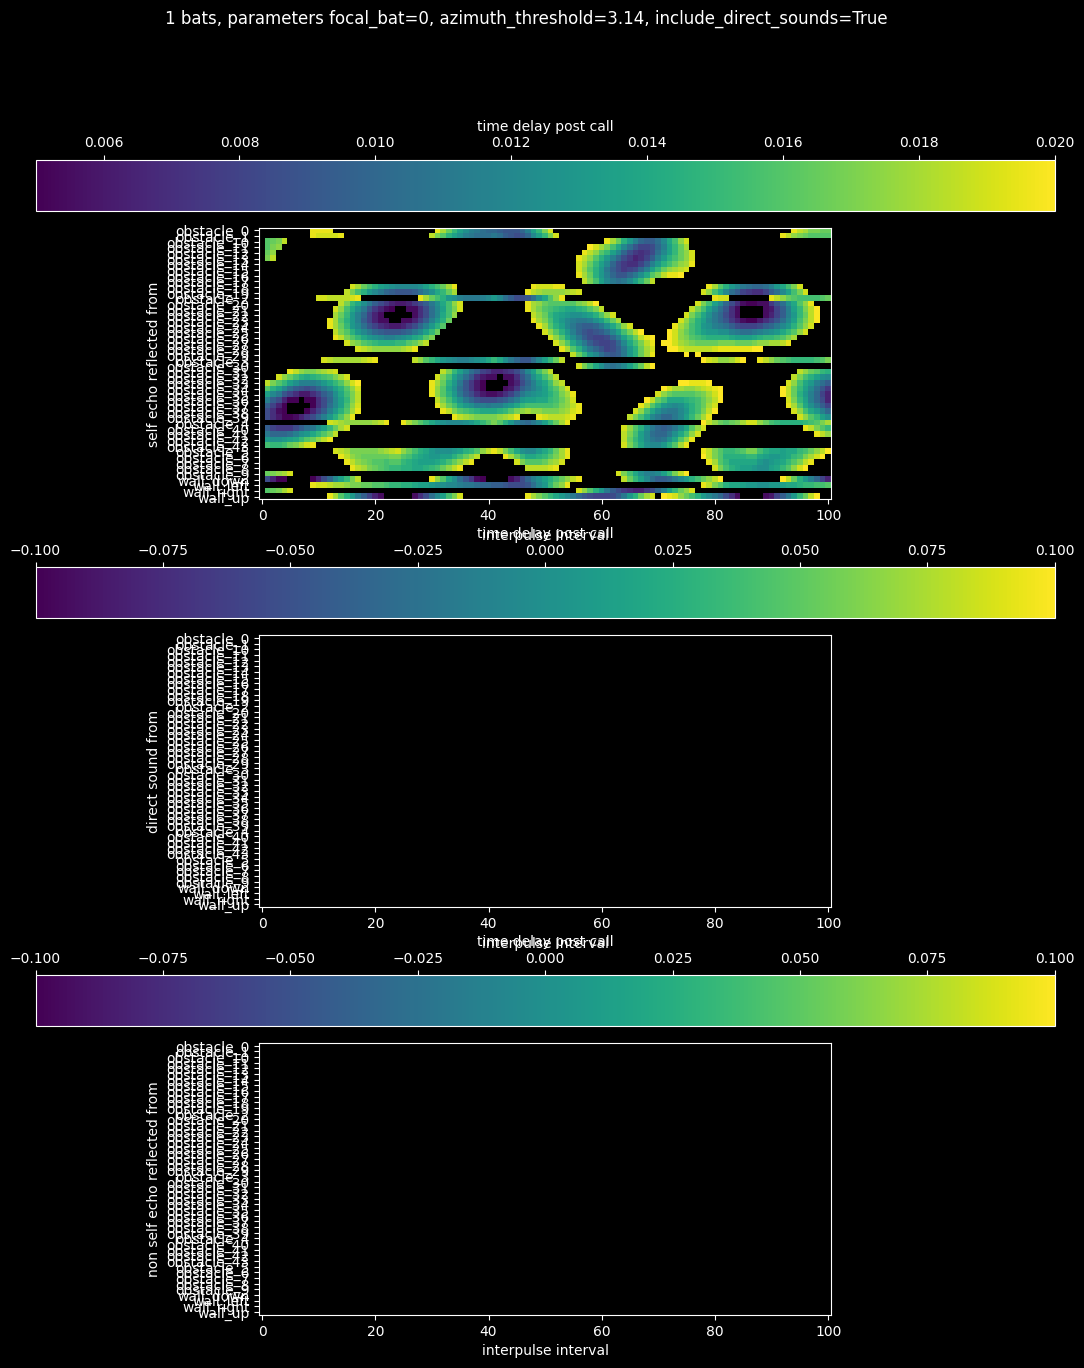

<Figure size 640x480 with 0 Axes>

In [26]:
for i, param in enumerate(ordered_list_of_parameters_sublist):
    FOCAL_BAT, INCLUDE_DIRECT_SOUNDS, AZIMUTH  = param
    
    list_of_matrices = store_matrices_given_param_delta_t[i]
    track_unique_objects = store_unique_objects_delta_t[i]
    masked_arrays_given_param = store_masked_array_delta_t[i]
    
    cmap_masked = mpl.cm.viridis
    cmap_masked.set_bad('black',1.)
    
    
    plt.figure(figsize=(15, 15))
    
    plt.subplot(3,1,1)
    plt.imshow(list_of_matrices[0], cmap = mpl.colormaps["viridis"])
    plt.colorbar(
        location="top",
        label="time delay post call",
    )
    plt.ylabel("self echo reflected from")
    plt.xlabel("interpulse interval")
    plt.yticks(
        labels=track_unique_objects, ticks=np.arange(0, list_of_matrices[0].shape[0])
    )
    plt.imshow(masked_arrays_given_param[0], interpolation='nearest', cmap=cmap_masked)
    plt.clim(0.005,0.02)
    
    plt.subplot(3,1,2)
    plt.imshow(list_of_matrices[1], cmap=mpl.colormaps["viridis"])
    plt.colorbar(
        location="top",
        label="time delay post call",
    )
    plt.ylabel("direct sound from")
    plt.xlabel("interpulse interval")
    plt.yticks(
        labels=track_unique_objects, ticks=np.arange(0, list_of_matrices[0].shape[0])
    )
    plt.imshow(masked_arrays_given_param[1], interpolation='nearest', cmap=cmap_masked)
    plt.clim(0.005,0.02)
    
    plt.subplot(3,1,3)
    plt.imshow(list_of_matrices[2], cmap=mpl.colormaps["viridis"])
    plt.colorbar(
        location="top",
        label="time delay post call",
    )
    plt.ylabel("non self echo reflected from")
    plt.xlabel("interpulse interval")
    plt.yticks(
        labels=track_unique_objects, ticks=np.arange(0, list_of_matrices[0].shape[0])
    )
    plt.imshow(masked_arrays_given_param[2], interpolation='nearest', cmap=cmap_masked)
    plt.clim(0.005,0.02)
    
    plt.suptitle(f"{NUM_BATS} bats, parameters focal_bat={FOCAL_BAT}, azimuth_threshold={np.round(AZIMUTH,2)}, include_direct_sounds={INCLUDE_DIRECT_SOUNDS}")
    # plt.tight_layout()
    plt.show()
    plt.clf()

Lets now make a circular grid to see if things occur consistenly in r and theta 


In [27]:
ANGULAR_RESOLUTION = np.pi/6 # radians
RADIAL_RESOLUTION = 0.002 #in seconds

# spatial_grid_r = np.arange(0.005,0.036,RADIAL_RESOLUTION)
# spatial_grid_theta = np.arange(-np.pi, np.pi, ANGULAR_RESOLUTION)
# matrix_spatial_grid = np.zeros(shape=(len(spatial_grid_r), len(spatial_grid_theta)))

#given time step
given_matrix_delta_t = nan_matrix_delta_t_direct.copy()
given_matrix_theta = nan_matrix_theta_direct.copy()

def convert_into_grids(heard_sounds_array, param):
    FOCAL_BAT, INCLUDE_DIRECT_SOUNDS, AZIMUTH  = param
    grid_labels= ["self_echoes", "direct_calls", "non_self_echoes"]
    
    spatial_grid_r = np.arange(0.005,0.02,RADIAL_RESOLUTION)
    spatial_grid_theta = np.arange(-np.pi, np.pi, ANGULAR_RESOLUTION)
    matrix_spatial_grid = np.zeros(shape=(len(spatial_grid_r), len(spatial_grid_theta)))
    
    counter=0
    store_grids = [matrix_spatial_grid.copy(), matrix_spatial_grid.copy(), matrix_spatial_grid.copy(), matrix_spatial_grid.copy()]
    for i, frame_heard_sounds in enumerate(heard_sounds_array):
        # store_grids = [matrix_spatial_grid.copy()]*3
        for sound_object in frame_heard_sounds:
            
            delta_t = np.array(sound_object["occurance_times"])[0] - sound_object["bat_last_call_time"]
            theta = sound_object["bat_direction"].angle_between(
                sound_object["incident_direction"]
            )
            
            
            grid_row_index = bisect.bisect_right(spatial_grid_r, delta_t) -1
            grid_column_index = bisect.bisect_right(spatial_grid_theta, theta) -1
            # print(FOCAL_BAT, sound_object["emitter_id"])
            if sound_object["emitter_id"] == FOCAL_BAT:
                
                index_for_storage = 0
                counter+=1
            elif sound_object["emitter_id"] != FOCAL_BAT and sound_object["type"] == "direct":
                index_for_storage = 1
            elif sound_object["emitter_id"] != FOCAL_BAT and sound_object["type"] == "echo":
                index_for_storage = 2
            # print(grid_row_index, grid_column_index)
            # if theta>-np.pi and theta<-5*np.pi/6:
            #     print(theta)
            store_grids[index_for_storage][grid_row_index, grid_column_index] +=1
            
    print(counter)   
    store_grids[3] = np.sum(store_grids[0:3], axis=0)
    return store_grids, spatial_grid_r, spatial_grid_theta
    
def convert_into_grids_time_series(heard_sounds_array, param):
    FOCAL_BAT, INCLUDE_DIRECT_SOUNDS, AZIMUTH  = param
    grid_labels= ["self_echoes", "direct_calls", "non_self_echoes"]
    
    spatial_grid_r = np.arange(0.005,0.02,RADIAL_RESOLUTION)
    spatial_grid_theta = np.arange(-np.pi, np.pi, ANGULAR_RESOLUTION)
    matrix_spatial_grid = np.zeros(shape=(len(spatial_grid_r), len(spatial_grid_theta)))
    
    store_grid_time_series = []
    counter=0
    for i, frame_heard_sounds in enumerate(heard_sounds_array):
        # store_grids = [matrix_spatial_grid.copy()]*3
        store_grids = [matrix_spatial_grid.copy(), matrix_spatial_grid.copy(), matrix_spatial_grid.copy(), matrix_spatial_grid.copy()]
        for sound_object in frame_heard_sounds:
            
            delta_t = np.array(sound_object["occurance_times"])[0] - sound_object["bat_last_call_time"]
            theta = sound_object["bat_direction"].angle_between(
                sound_object["incident_direction"]
            )
            
            
            grid_row_index = bisect.bisect_right(spatial_grid_r, delta_t) -1
            grid_column_index = bisect.bisect_right(spatial_grid_theta, theta) -1
            
            if sound_object["emitter_id"] == FOCAL_BAT:
                index_for_storage = 0
                counter+=1
            elif sound_object["emitter_id"] != FOCAL_BAT and sound_object["type"] == "direct":
                index_for_storage = 1
            elif sound_object["emitter_id"] != FOCAL_BAT and sound_object["type"] == "echo":
                index_for_storage = 2
            # print(grid_row_index, grid_column_index)
            # if theta>-np.pi and theta<-5*np.pi/6:
            #     print(theta)
            store_grids[index_for_storage][grid_row_index, grid_column_index] +=1
        store_grids[3] = np.sum(store_grids[0:3], axis=0)
        store_grid_time_series.append(store_grids)
    print(counter)
    return np.array(store_grid_time_series), spatial_grid_r, spatial_grid_theta

In [28]:
def convert_matrix_for_plotting_nicer(list_of_matrix, rows, columns, increase_resolution_by): #:( plot nice banane ke liye 
    angular_resolution = columns[1] - columns[0]
    new_angular_resolution = angular_resolution/increase_resolution_by
    new_column_labels = np.arange(-np.pi, np.pi, new_angular_resolution)
    
    # print(new_matrix.shape)
    new_list_of_matrix = []
    for matrix in list_of_matrix:
        new_matrix = np.zeros(shape=(len(rows), len(new_column_labels)-1)).copy()
        for i in range(new_matrix.shape[0]):
            for j in range(new_matrix.shape[1]):
                index_in_old_matrix = i, j//increase_resolution_by
                # print(index_in_old_matrix)
                new_matrix[i,j] = matrix[index_in_old_matrix]
        new_list_of_matrix.append(new_matrix)
    
    return new_list_of_matrix, new_angular_resolution
    

In [29]:
matrix, rows, column = convert_into_grids(dictionary_to_store_heard_sounds[param], param)
new_matrix, new_resolution = convert_matrix_for_plotting_nicer(matrix, rows, column, 10)

2091


In [30]:
matrix[0].shape
len(rows)

8

In [31]:
def plot_grid_matrix_into_radial(grid_matrix, spatial_grid_r, spatial_grid_theta, fig_and_ax):
    
    r, theta = np.meshgrid(spatial_grid_r, spatial_grid_theta)
    z = grid_matrix
    # plt.figure(figsize= (10,10))
    fig, axs = fig_and_ax
    im = axs.pcolormesh(theta, r, z, cmap = 'viridis')
    
    axs.set_thetagrids(range(0, 360, int(360/12)))
    axs.set_theta_zero_location("N")
    axs.set_theta_direction(-1)
    return im
    # plt.show()
# plt.plot(a, r, ls='none', color = 'k') 


    # plt.show()
# plt.plot(a, r, ls='none', color = 'k') 



2091


FileNotFoundError: [Errno 2] No such file or directory: './exploratory_analysis_plots/plots/grid_plot_detected_sounds_param_(0, True, 3.141592653589793).png'

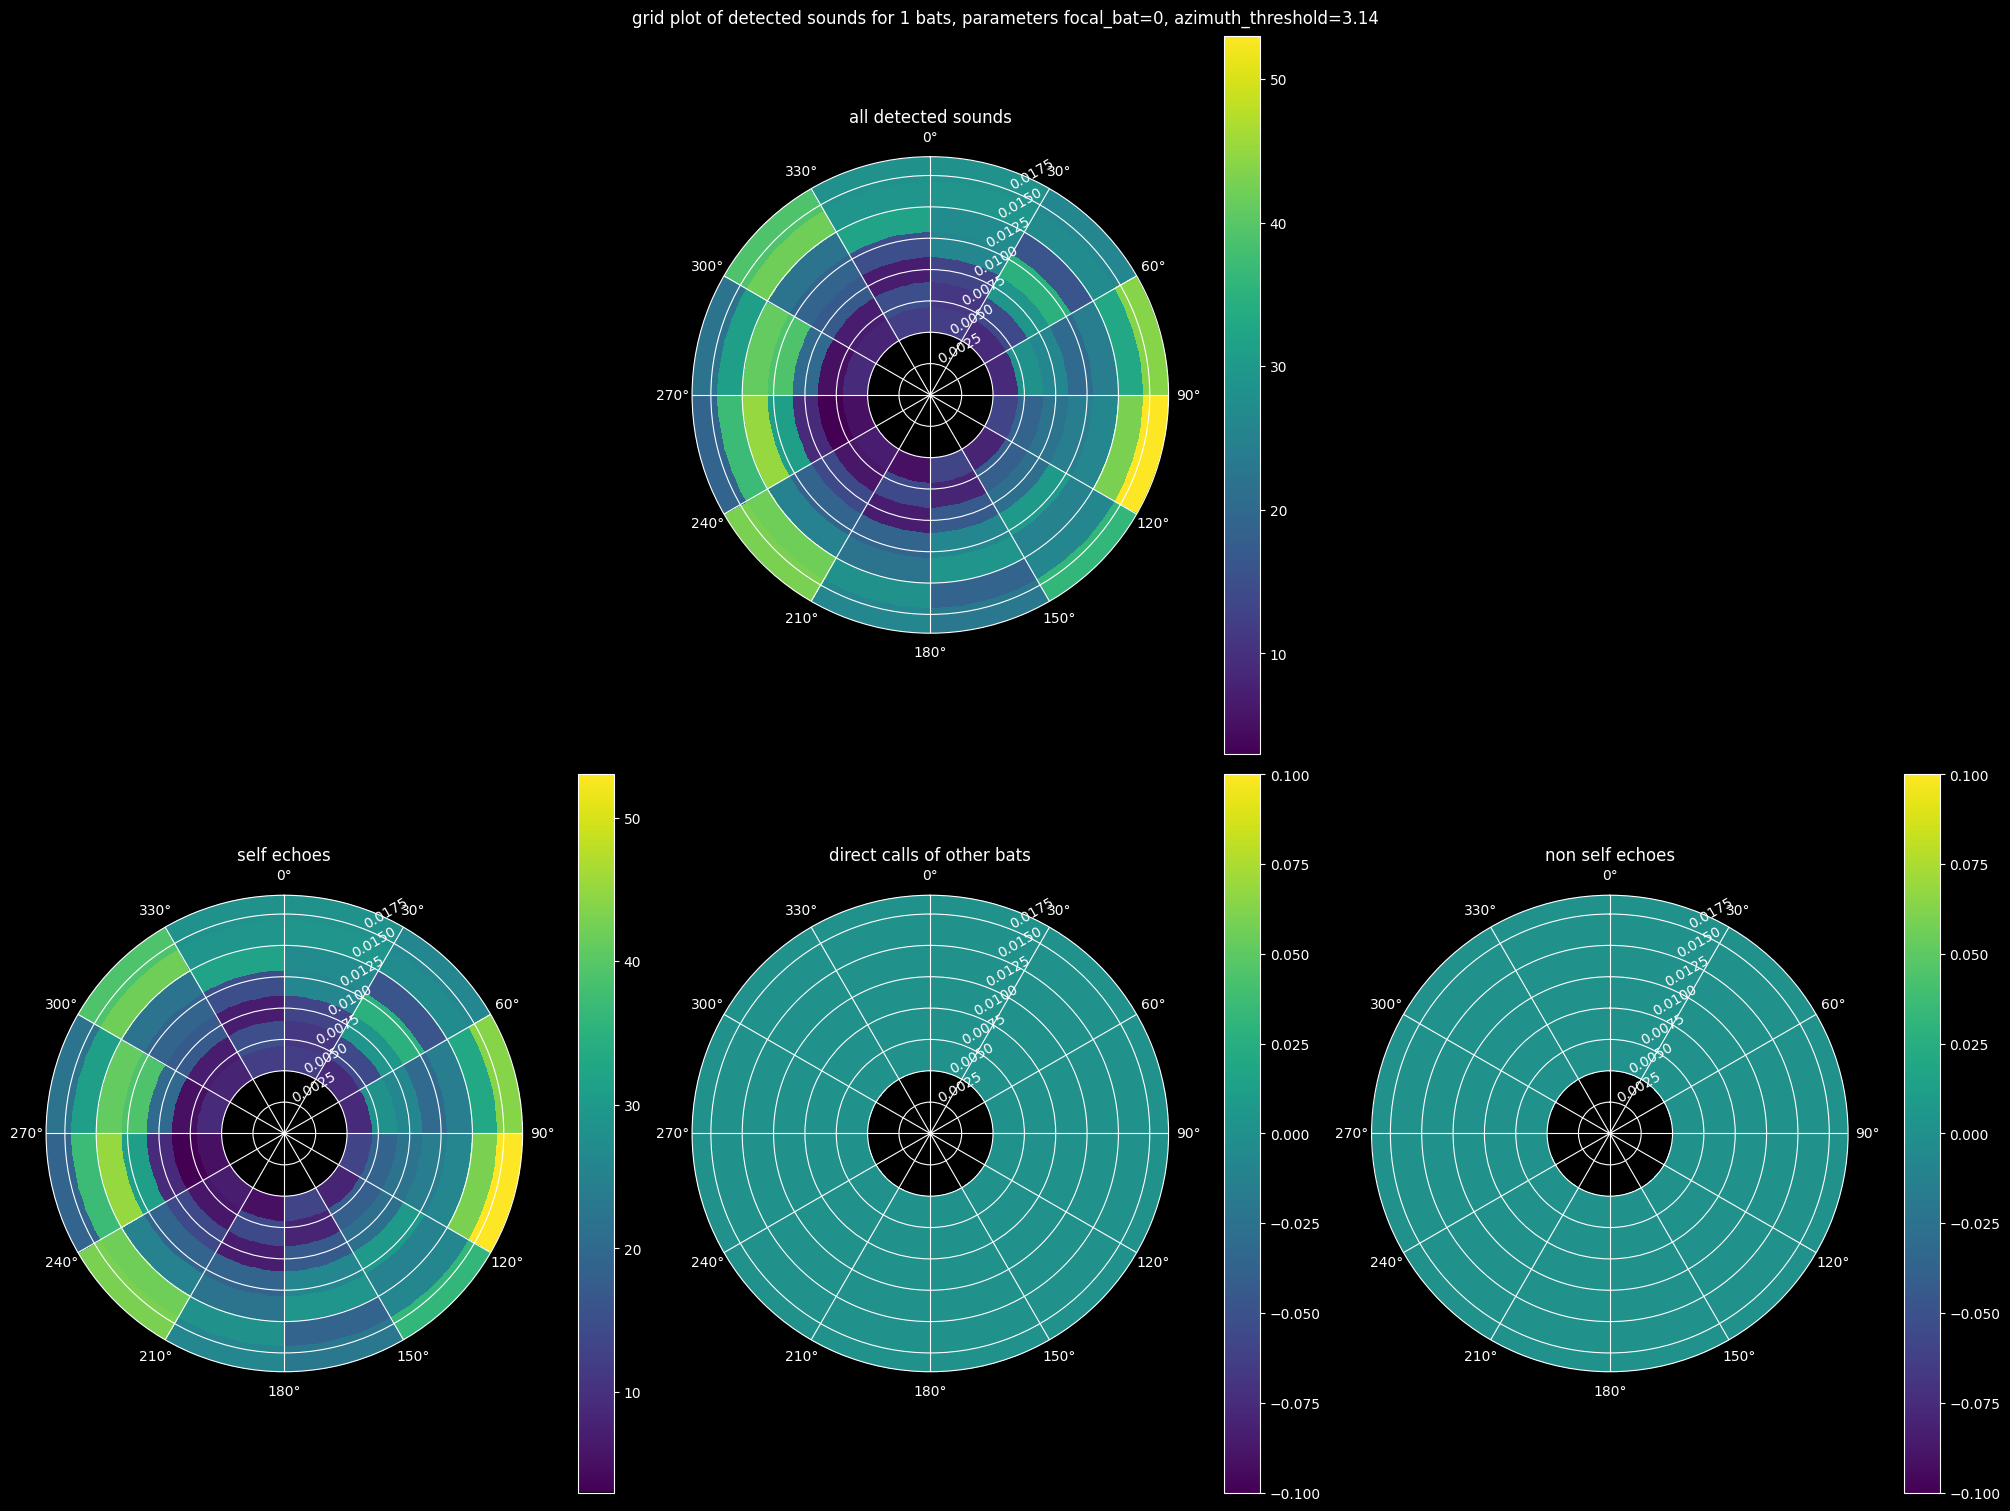

In [32]:
# %matplotlib inline
for param in ordered_list_of_parameters:
    
    FOCAL_BAT, INCLUDE_DIRECT_SOUNDS, AZIMUTH  = param
    heard_sounds_array = dictionary_to_store_heard_sounds[param]
    grid_data, rows, columns = convert_into_grids(heard_sounds_array, param)

    spatial_grid_r = np.arange(0.005+RADIAL_RESOLUTION/2,0.02,RADIAL_RESOLUTION)
    spatial_grid_theta = np.arange(-np.pi+ANGULAR_RESOLUTION/2, np.pi, ANGULAR_RESOLUTION)
    
    new_grid_data, new_angular_resolution = convert_matrix_for_plotting_nicer(grid_data, spatial_grid_r, spatial_grid_theta, 10)
    new_spatial_grid_theta = np.arange(-np.pi+new_angular_resolution/2, np.pi, new_angular_resolution)
    
    # plt.clf()
    # plt.close()
    fig, ax = plt.subplots(
                2,
                3,
                figsize=(20, 15),
                subplot_kw={"projection": "polar"},
                layout="constrained",
            )
    # print(len(new_spatial_grid_theta))
    # print(new_grid_data[0].shape)
    ax[1,0].set_title("self echoes")
    ax[1,1].set_title("direct calls of other bats")
    ax[1,2].set_title("non self echoes")
    ax[0,1].set_title("all detected sounds")
    
    ax[1,0].tick_params("y", rotation=30)
    ax[1,1].tick_params("y", rotation=30)
    ax[1,2].tick_params("y", rotation=30)
    ax[0,1].tick_params("y", rotation=30)
    
    plt.suptitle(f"grid plot of detected sounds for {NUM_BATS} bats, parameters focal_bat={FOCAL_BAT}, azimuth_threshold={np.round(AZIMUTH,2)}")
    fig.delaxes(ax[0,0])
    fig.delaxes(ax[0,2])
    im0= plot_grid_matrix_into_radial(new_grid_data[0].T, spatial_grid_r, new_spatial_grid_theta, fig_and_ax=(fig,ax[1,0]))
    im1= plot_grid_matrix_into_radial(new_grid_data[1].T, spatial_grid_r, new_spatial_grid_theta, fig_and_ax=(fig,ax[1,1]))
    im2= plot_grid_matrix_into_radial(new_grid_data[2].T, spatial_grid_r, new_spatial_grid_theta, fig_and_ax=(fig,ax[1,2]))
    im3= plot_grid_matrix_into_radial(new_grid_data[3].T, spatial_grid_r, new_spatial_grid_theta, fig_and_ax=(fig,ax[0,1]))
    fig.colorbar(im0)
    fig.colorbar(im1)
    fig.colorbar(im2)
    fig.colorbar(im3)
    plt.savefig(f"./exploratory_analysis_plots/plots/grid_plot_detected_sounds_param_{param}.png")
    # plt.close()
    plt.show()
    plt.clf()

In [33]:
def plot_grid_matrix_into_radial_time_series(grid_matrix, spatial_grid_r, spatial_grid_theta, fig_and_ax, cmin, cmax):
    # FOCAL_BAT, INCLUDE_DIRECT_SOUNDS, AZIMUTH  = param
    r, theta = np.meshgrid(spatial_grid_r, spatial_grid_theta)
    z = grid_matrix.T.copy()
    fig, axs = fig_and_ax
    
    masking_matrix = np.ma.masked_where(z==0, z)
    # div = make_axes_locatable(axs)
    # cax = div.append_axes('right', '5%', '5%')
    cmap = mpl.cm.get_cmap("autumn").copy()
    cmap.set_bad(color='black')
    im = axs.pcolormesh(theta, r, z, cmap = cmap)
    masker_im = axs.pcolormesh(theta, r, masking_matrix, cmap=cmap)
    im.set_clim(cmin,cmax)
    fig.colorbar(im)
    
    axs.set_thetagrids(range(0, 360, int(360/12)))
    axs.set_theta_zero_location("N")
    axs.set_theta_direction(-1)
    return im, masker_im

In [22]:
# import matplotlib.animation as animation
# plt.rcParams["animation.html"] = "jshtml"
# plt.rcParams['figure.dpi'] = 150  
# plt.rcParams["animation.ffmpeg_path"] = "/usr/bin/ffmpeg"
# plt.ioff()

# for param in ordered_list_of_parameters:
#     fig, ax = plt.subplots(
#                     1,
#                     1,
#                     figsize=(10, 10),
#                     subplot_kw={"projection": "polar"},
#                     layout="constrained",
#                 )

#     heard_sounds_array =dictionary_to_store_heard_sounds[param]
#     grid_data, spatial_grid_r, spatial_grid_theta = convert_into_grids(heard_sounds_array, param)
#     grid_data_time_series, spatial_grid_r, spatial_grid_theta = convert_into_grids_time_series(heard_sounds_array, param)
    
#     # spatial_grid_r = np.arange(0.005+RADIAL_RESOLUTION/2,0.035,RADIAL_RESOLUTION)
#     # spatial_grid_theta = np.arange(-np.pi+ANGULAR_RESOLUTION/2, np.pi, ANGULAR_RESOLUTION)


#     # plot_grid_matrix_into_radial(grid_data[0], spatial_grid_r, spatial_grid_theta, fig_and_ax=(fig,ax[0]))
#     # plot_grid_matrix_into_radial(grid_data[1], spatial_grid_r, spatial_grid_theta, fig_and_ax=(fig,ax[1]))
#     # plot_grid_matrix_into_radial(grid_data[2], spatial_grid_r, spatial_grid_theta, fig_and_ax=(fig,ax[2]))
#     # fig.suptitle("total counts across whole duration of simualtion")
#     # plt.show()
#     print(grid_data_time_series[0,0])
#     im, masker_im = plot_grid_matrix_into_radial_time_series(grid_data_time_series[0,0], spatial_grid_r, spatial_grid_theta, fig_and_ax=(fig,ax), cmin=0, cmax=4)
#     # plot_grid_matrix_into_radial_time_series(grid_data_time_series[0,1], spatial_grid_r, spatial_grid_theta, fig_and_ax=(fig,ax[1]), cmin=0, cmax=np.max(grid_data[1]))
#     # plot_grid_matrix_into_radial_time_series(grid_data_time_series[0,2], spatial_grid_r, spatial_grid_theta, fig_and_ax=(fig,ax[2]), cmin=0, cmax=np.max(grid_data[2]))
#     # plot_grid_matrix_into_radial_time_series(grid_data_time_series[0,3], spatial_grid_r, spatial_grid_theta, fig_and_ax=(fig,ax[3]), cmin=0, cmax=np.max(grid_data[2])+np.max(grid_data[1]))
#     def animate(t):
#         fig.suptitle(f"frame: {t}")
#         masker_matrix = np.ma.masked_where(grid_data_time_series[t,0].T==0, grid_data_time_series[t,0].T)
#         im.set_array(grid_data_time_series[t,0].T)
#         masker_im.set_array(masker_matrix)
#         # plot_grid_matrix_into_radial_time_series(grid_data_time_series[t,0], spatial_grid_r, spatial_grid_theta, fig_and_ax=(fig,ax), cmin=0, cmax=np.max(grid_data[0]))
#         # plot_grid_matrix_into_radial_time_series(grid_data_time_series[t,1], spatial_grid_r, spatial_grid_theta, fig_and_ax=(fig,ax[1]), cmin=0, cmax=np.max(grid_data[1]))
#         # plot_grid_matrix_into_radial_time_series(grid_data_time_series[t,2], spatial_grid_r, spatial_grid_theta, fig_and_ax=(fig,ax[2]), cmin=0, cmax=np.max(grid_data[2]))
#         # plot_grid_matrix_into_radial_time_series(grid_data_time_series[t,3], spatial_grid_r, spatial_grid_theta, fig_and_ax=(fig,ax[3]), cmin=0, cmax=np.max(grid_data[2])+np.max(grid_data[1]))
#         # plt.xlim(0,10)
#     ax.set_title("self_echoes")
#     # ax[1].set_title("direct")
#     # ax[2].set_title("non self echoes")
#     # ax[3].set_title("total")
#     ani = animation.FuncAnimation(fig, animate, frames= len(heard_sounds_array))
#     ffwriter = animation.FFMpegWriter(fps=10)
#     ani.save(f"self_echoes_animation_w_colorbar_{param}.mp4",writer=ffwriter)
#     plt.clf()
# plt.show()

In [36]:
import matplotlib.animation as animation
plt.rcParams["animation.html"] = "jshtml"
plt.rcParams['figure.dpi'] = 150  
plt.rcParams["animation.ffmpeg_path"] = "/usr/bin/ffmpeg"
plt.ioff()

for param in ordered_list_of_parameters:
    FOCAL_BAT, INCLUDE_DIRECT_SOUNDS, AZIMUTH  = param
    heard_sounds_array =dictionary_to_store_heard_sounds[param]
    grid_data, rows, columns = convert_into_grids(heard_sounds_array, param)
    grid_data_time_series, rows, columns = convert_into_grids_time_series(heard_sounds_array, param)
    
    spatial_grid_r = rows
    spatial_grid_theta =columns
    # spatial_grid_r = np.arange(0.005+RADIAL_RESOLUTION/2,0.02,RADIAL_RESOLUTION)
    # spatial_grid_theta = np.arange(-np.pi+ANGULAR_RESOLUTION/2, np.pi, ANGULAR_RESOLUTION)
    
    new_grid_data, new_angular_resolution = convert_matrix_for_plotting_nicer(grid_data, rows, columns, 10)
    new_grid_data_time_series = np.array([convert_matrix_for_plotting_nicer(i, rows, columns, 10)[0] for i in grid_data_time_series])
    new_spatial_grid_theta = np.arange(-np.pi+new_angular_resolution/2, np.pi, new_angular_resolution)
    
    # plt.clf()
    # plt.close()
    fig, ax = plt.subplots(
                2,
                3,
                figsize=(20, 15),
                subplot_kw={"projection": "polar"},
                layout="constrained",
            )
    print(len(new_spatial_grid_theta))
    print(new_grid_data[0].shape)
    ax[1,0].set_title("self echoes")
    ax[1,1].set_title("direct calls of other bats")
    ax[1,2].set_title("non self echoes")
    ax[0,1].set_title("all detected sounds")
    
    ax[1,0].tick_params("y", rotation=30)
    ax[1,1].tick_params("y", rotation=30)
    ax[1,2].tick_params("y", rotation=30)
    ax[0,1].tick_params("y", rotation=30)
    
    plt.suptitle(f"grid plot of detected sounds for {NUM_BATS} bats, parameters focal_bat={FOCAL_BAT}, azimuth_threshold={np.round(AZIMUTH,2)}")
    fig.delaxes(ax[0,0])
    fig.delaxes(ax[0,2])

    # plot_grid_matrix_into_radial(grid_data[0], spatial_grid_r, spatial_grid_theta, fig_and_ax=(fig,ax[0]))
    # plot_grid_matrix_into_radial(grid_data[1], spatial_grid_r, spatial_grid_theta, fig_and_ax=(fig,ax[1]))
    # plot_grid_matrix_into_radial(grid_data[2], spatial_grid_r, spatial_grid_theta, fig_and_ax=(fig,ax[2]))
    # fig.suptitle("total counts across whole duration of simualtion")
    # plt.show()
    im0, masker_im0 = plot_grid_matrix_into_radial_time_series(new_grid_data_time_series[0,0], spatial_grid_r, new_spatial_grid_theta, fig_and_ax=(fig,ax[1,0]), cmin=1, cmax=np.max(new_grid_data_time_series[:,0]))
    im1, masker_im1 = plot_grid_matrix_into_radial_time_series(new_grid_data_time_series[0,1], spatial_grid_r, new_spatial_grid_theta, fig_and_ax=(fig,ax[1,1]), cmin=1, cmax= np.max(new_grid_data_time_series[:,1]))
    im2, masker_im2 = plot_grid_matrix_into_radial_time_series(new_grid_data_time_series[0,2], spatial_grid_r, new_spatial_grid_theta, fig_and_ax=(fig,ax[1,2]), cmin=1, cmax= np.max(new_grid_data_time_series[:,2]))
    im3, masker_im3 = plot_grid_matrix_into_radial_time_series(new_grid_data_time_series[0,3], spatial_grid_r, new_spatial_grid_theta, fig_and_ax=(fig,ax[0,1]), cmin=1, cmax= np.max(new_grid_data_time_series[:,3]))
    # plot_grid_matrix_into_radial_time_series(grid_data_time_series[0,1], spatial_grid_r, spatial_grid_theta, fig_and_ax=(fig,ax[1]), cmin=0, cmax=np.max(grid_data[1]))
    # plot_grid_matrix_into_radial_time_series(grid_data_time_series[0,2], spatial_grid_r, spatial_grid_theta, fig_and_ax=(fig,ax[2]), cmin=0, cmax=np.max(grid_data[2]))
    # plot_grid_matrix_into_radial_time_series(grid_data_time_series[0,3], spatial_grid_r, spatial_grid_theta, fig_and_ax=(fig,ax[3]), cmin=0, cmax=np.max(grid_data[2])+np.max(grid_data[1]))
    ipi_counter = plt.figtext(.01, .6, f"interpulse interval number : {0}", fontsize=30, ha='left', va='top')
    def animate(t):
        # fig.suptitle(f"frame: {t}")
        ipi_counter.set_text(f"interpulse interval number : {t}")
        masker_matrix0 = np.ma.masked_where(new_grid_data_time_series[t,0].T==0, new_grid_data_time_series[t,0].T)
        im0.set_array(new_grid_data_time_series[t,0].T)
        masker_im0.set_array(masker_matrix0)
        
        masker_matrix1 = np.ma.masked_where(new_grid_data_time_series[t,1].T==0, new_grid_data_time_series[t,1].T)
        im1.set_array(new_grid_data_time_series[t,1].T)
        masker_im1.set_array(masker_matrix1)
        
        masker_matrix2 = np.ma.masked_where(new_grid_data_time_series[t,2].T==0, new_grid_data_time_series[t,2].T)
        im2.set_array(new_grid_data_time_series[t,2].T)
        masker_im2.set_array(masker_matrix2)
        
        masker_matrix3 = np.ma.masked_where(new_grid_data_time_series[t,3].T==0, new_grid_data_time_series[t,3].T)
        im3.set_array(new_grid_data_time_series[t,3].T)
        masker_im3.set_array(masker_matrix3)

    
    ani = animation.FuncAnimation(fig, animate, frames= len(heard_sounds_array))
    ffwriter = animation.FFMpegWriter(fps=10)
    ani.save(f"35_ms_self_echoes_animation_w_colorbar_focal_bat_{FOCAL_BAT}_azimuth_threshold_{np.round(AZIMUTH,2)}_test.mp4",writer=ffwriter)
    plt.clf()
# plt.show()

2091
2091
120
(8, 120)


/tmp/ipykernel_93577/3933430808.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("autumn").copy()


In [24]:
new_grid_data_time_series[0,0].shape

(8, 120)

In [25]:
spatial_grid_r

array([0.005, 0.007, 0.009, 0.011, 0.013, 0.015, 0.017, 0.019])

In [26]:
new_grid_data_time_series

array([[[[ 0.,  0.,  0., ...,  0.,  0.,  0.],
         [ 0.,  0.,  0., ...,  0.,  0.,  0.],
         [ 0.,  0.,  0., ...,  0.,  0.,  0.],
         ...,
         [ 0.,  0.,  0., ...,  0.,  0.,  0.],
         [ 0.,  0.,  0., ...,  0.,  0.,  0.],
         [ 0.,  0.,  0., ...,  0.,  0.,  0.]],

        [[ 0.,  0.,  0., ...,  0.,  0.,  0.],
         [ 0.,  0.,  0., ...,  0.,  0.,  0.],
         [ 0.,  0.,  0., ...,  0.,  0.,  0.],
         ...,
         [ 0.,  0.,  0., ...,  0.,  0.,  0.],
         [ 0.,  0.,  0., ...,  0.,  0.,  0.],
         [ 0.,  0.,  0., ...,  0.,  0.,  0.]],

        [[ 0.,  0.,  0., ...,  0.,  0.,  0.],
         [ 0.,  0.,  0., ...,  0.,  0.,  0.],
         [ 0.,  0.,  0., ...,  0.,  0.,  0.],
         ...,
         [ 0.,  0.,  0., ...,  0.,  0.,  0.],
         [ 0.,  0.,  0., ...,  0.,  0.,  0.],
         [ 0.,  0.,  0., ...,  0.,  0.,  0.]],

        [[ 0.,  0.,  0., ...,  0.,  0.,  0.],
         [ 0.,  0.,  0., ...,  0.,  0.,  0.],
         [ 0.,  0.,  0., ...,  0

In [35]:
grid_data = convert_into_grids(heard_sounds_array)
grid_data_time_series = convert_into_grids_time_series(heard_sounds_array)

# print(grid_data[0])
print(np.max(grid_data[0]))

TypeError: convert_into_grids() missing 1 required positional argument: 'param'